# Classificacao via Rede Neural (MLP) - SLCE3 (Dataset Indicadores)
## Analise comparativa de modelos de Machine Learning - Agro Brasil - TCC

Este notebook implementa modelos de classificacao binaria via rede neural (MLPClassifier) para prever se o preco de fechamento das acoes SLCE3 ira subir ou nao em diferentes horizontes temporais (3, 7, 15 e 30 dias).

**Dataset utilizado:** Dataset indicadores (OHLC + indicadores agro + indicadores tecnicos de mercado).

**Target:** Classificacao binaria (1 = Alta, 0 = Baixa/Estavel)

**Metodologia:** Train+Validacao (80%) + Validacao Cruzada Estratificada (5 folds) + Teste Final Holdout (20%), com calibracao de threshold por curva Precision-Recall.

**Pipeline anti-leakage:** `SimpleImputer(mediana) -> StandardScaler -> MLPClassifier(solver='adam', early_stopping=True, max_iter=1000)`


### Importacao das bibliotecas e carregamento do dataset


In [1]:
import pandas as pd
import numpy as np
from typing import cast
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve,
                             precision_recall_curve)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# Configuracao para salvar graficos
OUTPUT_DIR = './'
os.makedirs(OUTPUT_DIR, exist_ok=True)

COMPANY = 'SLCE3'
DATASET_LABEL = 'indicadores'
DATASET_NAME = 'Indicadores'
DATASET_DIR = 'datasets_indicadores'
company_lower = COMPANY.lower()

# Carrega o dataset tratado para classificacao
df = pd.read_csv(f'../../../../datasets/{DATASET_DIR}/classificacao/{COMPANY}_tratado.csv', index_col=0, parse_dates=True)

print('='*60)
print(f'DATASET {COMPANY} - CLASSIFICACAO VIA REDE NEURAL ({DATASET_LABEL.upper()})')
print('='*60)
print(f'\nShape: {df.shape}')
print('\nColunas disponiveis:')
print(df.columns.tolist())
print('\nPrimeiras 5 linhas:')
print(df.head())
print('\nDistribuicao das classes target:')
for col in ['target_3d', 'target_7d', 'target_15d', 'target_30d']:
    if col in df.columns:
        dist = df[col].value_counts()
        pct = df[col].mean()
        print(f'  {col}: {dist.to_dict()} (Taxa de alta: {pct:.1%})')

print('\nImputacao de ausentes sera feita DENTRO do Pipeline (SimpleImputer), apos o split.')


DATASET SLCE3 - CLASSIFICACAO VIA REDE NEURAL (INDICADORES)

Shape: (1633, 24)

Colunas disponiveis:
['Close', 'High', 'Low', 'Open', 'Volume', 'agro_soja_close_lag_1d', 'agro_soja_close_lag_3d', 'agro_soja_close_lag_6d', 'agro_soja_close_lag_10d', 'agro_cambio_close_lag_1d', 'agro_cambio_close_lag_3d', 'agro_cambio_close_lag_6d', 'agro_cambio_close_lag_10d', 'target_3d', 'target_7d', 'target_15d', 'target_30d', 'OBV', 'FWMA', 'TEMA', 'HLC3', 'BB_upper', 'BB_middle', 'BB_lower']

Primeiras 5 linhas:
               Close      High       Low      Open   Volume  \
Date                                                          
2018-02-15  3.729142  3.812630  3.721349  3.807064  8115228   
2018-02-16  3.704652  3.771443  3.682388  3.751405  1686256   
2018-02-20  3.740273  3.773669  3.695747  3.706878   897336   
2018-02-21  3.677936  3.789253  3.677936  3.741386  1346972   
2018-02-22  3.697973  3.799272  3.623390  3.702426  1547832   

            agro_soja_close_lag_1d  agro_soja_close_l

### Preparacao dos dados para modelagem


In [2]:
# Definir features: base (OHLC) + indicadores agro (lags) + extras
base_features = ['Close', 'Low', 'High', 'Open']
agro_lag_features = ['agro_cambio_close_lag_1d', 'agro_cambio_close_lag_3d', 'agro_cambio_close_lag_6d', 'agro_cambio_close_lag_10d', 'agro_soja_close_lag_1d', 'agro_soja_close_lag_3d', 'agro_soja_close_lag_6d', 'agro_soja_close_lag_10d']
technical_indicators = ['OBV', 'FWMA', 'TEMA', 'HLC3', 'BB_upper', 'BB_middle', 'BB_lower']
all_features = base_features + agro_lag_features + technical_indicators

X = df[all_features].copy()

# Definir targets (variaveis dependentes) - classificacao binaria
targets = {
    '3d': df['target_3d'],
    '7d': df['target_7d'],
    '15d': df['target_15d'],
    '30d': df['target_30d']
}

print('Variaveis independentes (X):')
print(X.columns.tolist())
print(f'\nShape de X: {X.shape}')
print(f'\nComposicao de features:')
print(f'  - Base features ({len(base_features)}): {base_features}')
print(f'  - Indicadores agro ({len(agro_lag_features)}): {agro_lag_features}')
print(f'  - technical_indicators ({len(technical_indicators)}): {technical_indicators}')
print(f'  - Total: {len(all_features)} features')

print('\nTargets (classificacao binaria):')
for name, target in targets.items():
    print(f'  - {name}: {target.name} (1=Alta, 0=Baixa)')


Variaveis independentes (X):
['Close', 'Low', 'High', 'Open', 'agro_cambio_close_lag_1d', 'agro_cambio_close_lag_3d', 'agro_cambio_close_lag_6d', 'agro_cambio_close_lag_10d', 'agro_soja_close_lag_1d', 'agro_soja_close_lag_3d', 'agro_soja_close_lag_6d', 'agro_soja_close_lag_10d', 'OBV', 'FWMA', 'TEMA', 'HLC3', 'BB_upper', 'BB_middle', 'BB_lower']

Shape de X: (1633, 19)

Composicao de features:
  - Base features (4): ['Close', 'Low', 'High', 'Open']
  - Indicadores agro (8): ['agro_cambio_close_lag_1d', 'agro_cambio_close_lag_3d', 'agro_cambio_close_lag_6d', 'agro_cambio_close_lag_10d', 'agro_soja_close_lag_1d', 'agro_soja_close_lag_3d', 'agro_soja_close_lag_6d', 'agro_soja_close_lag_10d']
  - technical_indicators (7): ['OBV', 'FWMA', 'TEMA', 'HLC3', 'BB_upper', 'BB_middle', 'BB_lower']
  - Total: 19 features

Targets (classificacao binaria):
  - 3d: target_3d (1=Alta, 0=Baixa)
  - 7d: target_7d (1=Alta, 0=Baixa)
  - 15d: target_15d (1=Alta, 0=Baixa)
  - 30d: target_30d (1=Alta, 0=Baixa

In [3]:
# Definir CV estratificada: 5 folds mantendo proporcao de classes
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Definir espaco de hiperparametros para busca aleatoria (MLPClassifier)
param_dist = {
    'model__hidden_layer_sizes': [(32,), (64,), (128,), (64, 32), (128, 64), (128, 64, 32)],
    'model__activation': ['relu', 'tanh', 'logistic'],
    'model__alpha': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
    'model__learning_rate_init': [1e-4, 5e-4, 1e-3, 5e-3, 1e-2]
}

print('='*60)
print('CONFIGURACAO DA VALIDACAO CRUZADA')
print('='*60)
print('\nEstrategia CV: StratifiedKFold')
print('  - N splits (folds): 5')
print('  - Shuffle: True')
print('  - Random state: 42')

print('\nEspaco de hiperparametros (MLPClassifier dentro do Pipeline):')
print(f"  - hidden_layer_sizes: {param_dist['model__hidden_layer_sizes']}")
print(f"  - activation: {param_dist['model__activation']}")
print(f"  - alpha (regularizacao L2): {param_dist['model__alpha']}")
print(f"  - learning_rate_init: {param_dist['model__learning_rate_init']}")

print('\nConfiguracao fixa do MLPClassifier:')
print('  - solver: adam')
print('  - early_stopping: True')
print('  - max_iter: 1000')
print('  - random_state: 42')

print('\nScoring metric: f1 (foco direto na classe positiva)')

print('\n' + '='*70)
print('DIAGNOSTICO DE DESBALANCEAMENTO POR HORIZONTE')
print('='*70)
for period, y in targets.items():
    y_clean = y.dropna()
    dist = y_clean.value_counts().sort_index()

    n0 = int(dist.get(0, 0))
    n1 = int(dist.get(1, 0))
    total = n0 + n1

    if total == 0:
        print(f'\n{period.upper()}: sem dados')
        continue

    p0 = n0 / total
    p1 = n1 / total
    major = max(n0, n1)
    minor = min(n0, n1)

    ratio_txt = 'infinito (apenas uma classe)' if minor == 0 else f'{(major / minor):.2f}:1'
    baseline_acc = major / total

    print(f'\nHorizonte {period.upper()}')
    print(f'  Classe 0 (Baixa/Estavel): {n0} ({p0:.1%})')
    print(f'  Classe 1 (Alta):          {n1} ({p1:.1%})')
    print(f'  Razao majoritaria/minoritaria: {ratio_txt}')
    print(f'  Baseline ingenua (sempre majoritaria): Accuracy = {baseline_acc:.4f}')


CONFIGURACAO DA VALIDACAO CRUZADA

Estrategia CV: StratifiedKFold
  - N splits (folds): 5
  - Shuffle: True
  - Random state: 42

Espaco de hiperparametros (MLPClassifier dentro do Pipeline):
  - hidden_layer_sizes: [(32,), (64,), (128,), (64, 32), (128, 64), (128, 64, 32)]
  - activation: ['relu', 'tanh', 'logistic']
  - alpha (regularizacao L2): [1e-05, 0.0001, 0.001, 0.01, 0.1]
  - learning_rate_init: [0.0001, 0.0005, 0.001, 0.005, 0.01]

Configuracao fixa do MLPClassifier:
  - solver: adam
  - early_stopping: True
  - max_iter: 1000
  - random_state: 42

Scoring metric: f1 (foco direto na classe positiva)

DIAGNOSTICO DE DESBALANCEAMENTO POR HORIZONTE

Horizonte 3D
  Classe 0 (Baixa/Estavel): 810 (49.6%)
  Classe 1 (Alta):          823 (50.4%)
  Razao majoritaria/minoritaria: 1.02:1
  Baseline ingenua (sempre majoritaria): Accuracy = 0.5040

Horizonte 7D
  Classe 0 (Baixa/Estavel): 775 (47.5%)
  Classe 1 (Alta):          858 (52.5%)
  Razao majoritaria/minoritaria: 1.11:1
  Baselin

### Configuracao da Validacao Cruzada Estratificada


### Treinamento dos Modelos MLPClassifier com RandomizedSearchCV


In [4]:
print('TREINAMENTO CLASSIFICACAO VIA REDE NEURAL - SLCE3 (COM VALIDACAO CRUZADA ESTRATIFICADA)')
print('='*60)

models = {}
search_results = {}

for period, y in targets.items():
    print(f'\n\n{"="*60}')
    print(f'PERIODO: {period.upper()}')
    print(f'{"="*60}')

    # Remover NaN do target
    mask = ~y.isnull()
    X_clean = X.loc[mask].copy()
    y_clean = y.loc[mask].copy()

    print('\n1. SEPARACAO INICIAL (Train+Val vs Teste Final)')
    print(f'   Dados elegiveis: {X_clean.shape[0]} amostras')

    # Step 1: Separar teste final (holdout estratificado)
    X_dev, X_test, y_dev, y_test = train_test_split(
        X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean, shuffle=True
    )

    print(f'   - Desenvolvimento (Train+Val): {X_dev.shape[0]} amostras')
    print(f'   - Teste Final (Holdout): {X_test.shape[0]} amostras')
    print(f'   - Proporcao classe 1 Dev: {y_dev.mean():.1%}')
    print(f'   - Proporcao classe 1 Teste: {y_test.mean():.1%}')

    print('\n2. BUSCA DE HIPERPARAMETROS (RandomizedSearchCV + StratifiedKFold)')

    # Step 2: Pipeline com imputacao + escala obrigatoria para rede neural
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', MLPClassifier(
            solver='adam',
            early_stopping=True,
            max_iter=1000,
            random_state=42
        ))
    ])

    # Step 3: RandomizedSearchCV com StratifiedKFold
    random_search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_dist,
        n_iter=16,
        scoring='f1',
        cv=cv_strategy,
        n_jobs=-1,
        random_state=42,
        verbose=0
    )

    print('   - N iteracoes (combinacoes aleatorias): 16')
    print('   - CV folds: 5')
    print('   - Metrica de selecao: f1 (classe positiva)')
    print('   - Treinando...')

    random_search.fit(X_dev, y_dev)

    best_pipeline = cast(Pipeline, random_search.best_estimator_)
    best_params = random_search.best_params_
    best_cv_score = random_search.best_score_

    print('\n   OK - Busca concluida!')
    print(f'   - Melhor F1 (CV): {best_cv_score:.4f}')
    print('   - Melhores parametros:')
    for param, value in sorted(best_params.items()):
        print(f'       {param}: {value}')

    print('\n3. CALIBRACAO DE THRESHOLD (Precision-Recall no conjunto de validacao CV)')

    # Out-of-fold probabilities em X_dev para calibrar threshold sem usar o teste final
    oof_pred_proba = cross_val_predict(
        best_pipeline, X_dev, y_dev, cv=cv_strategy, method='predict_proba', n_jobs=-1
    )[:, 1]

    precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_dev, oof_pred_proba)
    f1_vals_pr = 2 * (precision_vals * recall_vals) / (precision_vals + recall_vals + 1e-12)

    if len(pr_thresholds) > 0:
        best_idx = np.argmax(f1_vals_pr[:-1])
        optimal_threshold = float(pr_thresholds[best_idx])
        val_precision = float(precision_vals[best_idx])
        val_recall = float(recall_vals[best_idx])
        val_f1 = float(f1_vals_pr[best_idx])
    else:
        optimal_threshold = 0.5
        val_precision = precision_score(y_dev, (oof_pred_proba >= 0.5).astype(int), zero_division=0)
        val_recall = recall_score(y_dev, (oof_pred_proba >= 0.5).astype(int), zero_division=0)
        val_f1 = f1_score(y_dev, (oof_pred_proba >= 0.5).astype(int), zero_division=0)

    print(f'   - Threshold otimo (PR): {optimal_threshold:.4f}')
    print(f'   - Precision validacao (OOF): {val_precision:.4f}')
    print(f'   - Recall validacao (OOF): {val_recall:.4f}')
    print(f'   - F1 validacao (OOF): {val_f1:.4f}')

    print('\n4. AVALIACAO NO TESTE FINAL (holdout) COM THRESHOLD CALIBRADO')

    # Refit final no conjunto de desenvolvimento completo e avaliacao no teste
    best_pipeline.fit(X_dev, y_dev)
    y_pred_proba = best_pipeline.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_proba >= optimal_threshold).astype(int)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    precision_alta = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    recall_alta = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1_alta = f1_score(y_test, y_pred, pos_label=1, zero_division=0)

    auc_roc = roc_auc_score(y_test, y_pred_proba)

    mlp_model = best_pipeline.named_steps['model']

    print('   Metricas no Teste Final (20%) com threshold calibrado:')
    print(f'   - Threshold aplicado: {optimal_threshold:.4f}')
    print(f'   - Accuracy: {accuracy:.4f}')
    print(f'   - Precision (weighted): {precision:.4f}')
    print(f'   - Recall (weighted): {recall:.4f}')
    print(f'   - F1-Score (weighted): {f1:.4f}')
    print(f'   - AUC-ROC: {auc_roc:.4f}')
    print(f'   - N iteracoes ate convergencia: {mlp_model.n_iter_}')
    print(f'   - Loss final (dev): {getattr(mlp_model, "loss_", float("nan")):.6f}')
    print('   ')
    print('   Metricas Classe Alta no Teste Final:')
    print(f'   - Precision: {precision_alta:.4f}')
    print(f'   - Recall: {recall_alta:.4f}')
    print(f'   - F1-Score: {f1_alta:.4f}')

    models[period] = {
        'pipeline': best_pipeline,
        'best_params': best_params,
        'best_cv_score': best_cv_score,
        'optimal_threshold': optimal_threshold,
        'val_precision_oof': val_precision,
        'val_recall_oof': val_recall,
        'val_f1_oof': val_f1,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'precision_alta': precision_alta,
        'recall_alta': recall_alta,
        'f1_alta': f1_alta,
        'auc_roc': auc_roc,
        'X_train': X_dev,
        'X_test': X_test,
        'y_train': y_dev,
        'y_test': y_test,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'oof_pred_proba': oof_pred_proba,
        'search_object': random_search
    }

    search_results[period] = {
        'best_cv_score': best_cv_score,
        'best_params': best_params,
        'optimal_threshold': optimal_threshold,
        'oof_f1_at_optimal_threshold': val_f1,
        'test_accuracy': accuracy,
        'test_f1': f1,
        'test_f1_alta': f1_alta
    }

print('\n' + '='*60)
print('OK - 4 modelos treinados com validacao cruzada e threshold calibrado!')
print('='*60)


TREINAMENTO CLASSIFICACAO VIA REDE NEURAL - SLCE3 (COM VALIDACAO CRUZADA ESTRATIFICADA)


PERIODO: 3D

1. SEPARACAO INICIAL (Train+Val vs Teste Final)
   Dados elegiveis: 1633 amostras
   - Desenvolvimento (Train+Val): 1306 amostras
   - Teste Final (Holdout): 327 amostras
   - Proporcao classe 1 Dev: 50.4%
   - Proporcao classe 1 Teste: 50.5%

2. BUSCA DE HIPERPARAMETROS (RandomizedSearchCV + StratifiedKFold)
   - N iteracoes (combinacoes aleatorias): 16
   - CV folds: 5
   - Metrica de selecao: f1 (classe positiva)
   - Treinando...

   OK - Busca concluida!
   - Melhor F1 (CV): 0.6701
   - Melhores parametros:
       model__activation: logistic
       model__alpha: 0.01
       model__hidden_layer_sizes: (128, 64, 32)
       model__learning_rate_init: 0.0001

3. CALIBRACAO DE THRESHOLD (Precision-Recall no conjunto de validacao CV)
   - Threshold otimo (PR): 0.6692
   - Precision validacao (OOF): 0.5038
   - Recall validacao (OOF): 1.0000
   - F1 validacao (OOF): 0.6701

4. AVALIACAO

### Tabela Resumo das Metricas


In [5]:
# Criar DataFrame com resumo das metricas (CV + OOF + Teste Holdout)
periods = ['3d', '7d', '15d', '30d']
metrics_summary = pd.DataFrame({
    'Horizonte': ['3 dias', '7 dias', '15 dias', '30 dias'],
    'CV_F1_Best': [models[p]['best_cv_score'] for p in periods],
    'Threshold_Otimo': [models[p]['optimal_threshold'] for p in periods],
    'OOF_F1_Threshold': [models[p]['val_f1_oof'] for p in periods],
    'Teste_Accuracy': [models[p]['accuracy'] for p in periods],
    'Teste_F1_Weighted': [models[p]['f1'] for p in periods],
    'Teste_F1_Classe_Alta': [models[p]['f1_alta'] for p in periods],
    'Teste_AUC_ROC': [models[p]['auc_roc'] for p in periods]
})

print('\nRESUMO DAS METRICAS - SLCE3 (INDICADORES)')
print('='*100)
print(metrics_summary.round(4).to_string(index=False))

# Salvar metricas em CSV
metrics_summary.to_csv(f'{OUTPUT_DIR}metricas_{company_lower}_{DATASET_LABEL}.csv', index=False)
print(f'\nOK - Metricas salvas em metricas_{company_lower}_{DATASET_LABEL}.csv')



RESUMO DAS METRICAS - SLCE3 (INDICADORES)
Horizonte  CV_F1_Best  Threshold_Otimo  OOF_F1_Threshold  Teste_Accuracy  Teste_F1_Weighted  Teste_F1_Classe_Alta  Teste_AUC_ROC
   3 dias      0.6701           0.6692            0.6701          0.4954             0.3388                0.0237         0.4193
   7 dias      0.6888           0.6693            0.6895          0.4495             0.2940                0.0000         0.3889
  15 dias      0.7674           0.4667            0.7720          0.8043             0.8033                0.8242         0.8711
  30 dias      0.8155           0.4296            0.8269          0.8471             0.8458                0.8670         0.9245

OK - Metricas salvas em metricas_slce3_indicadores.csv


---
# Analises Graficas


### Matrizes de Confusao


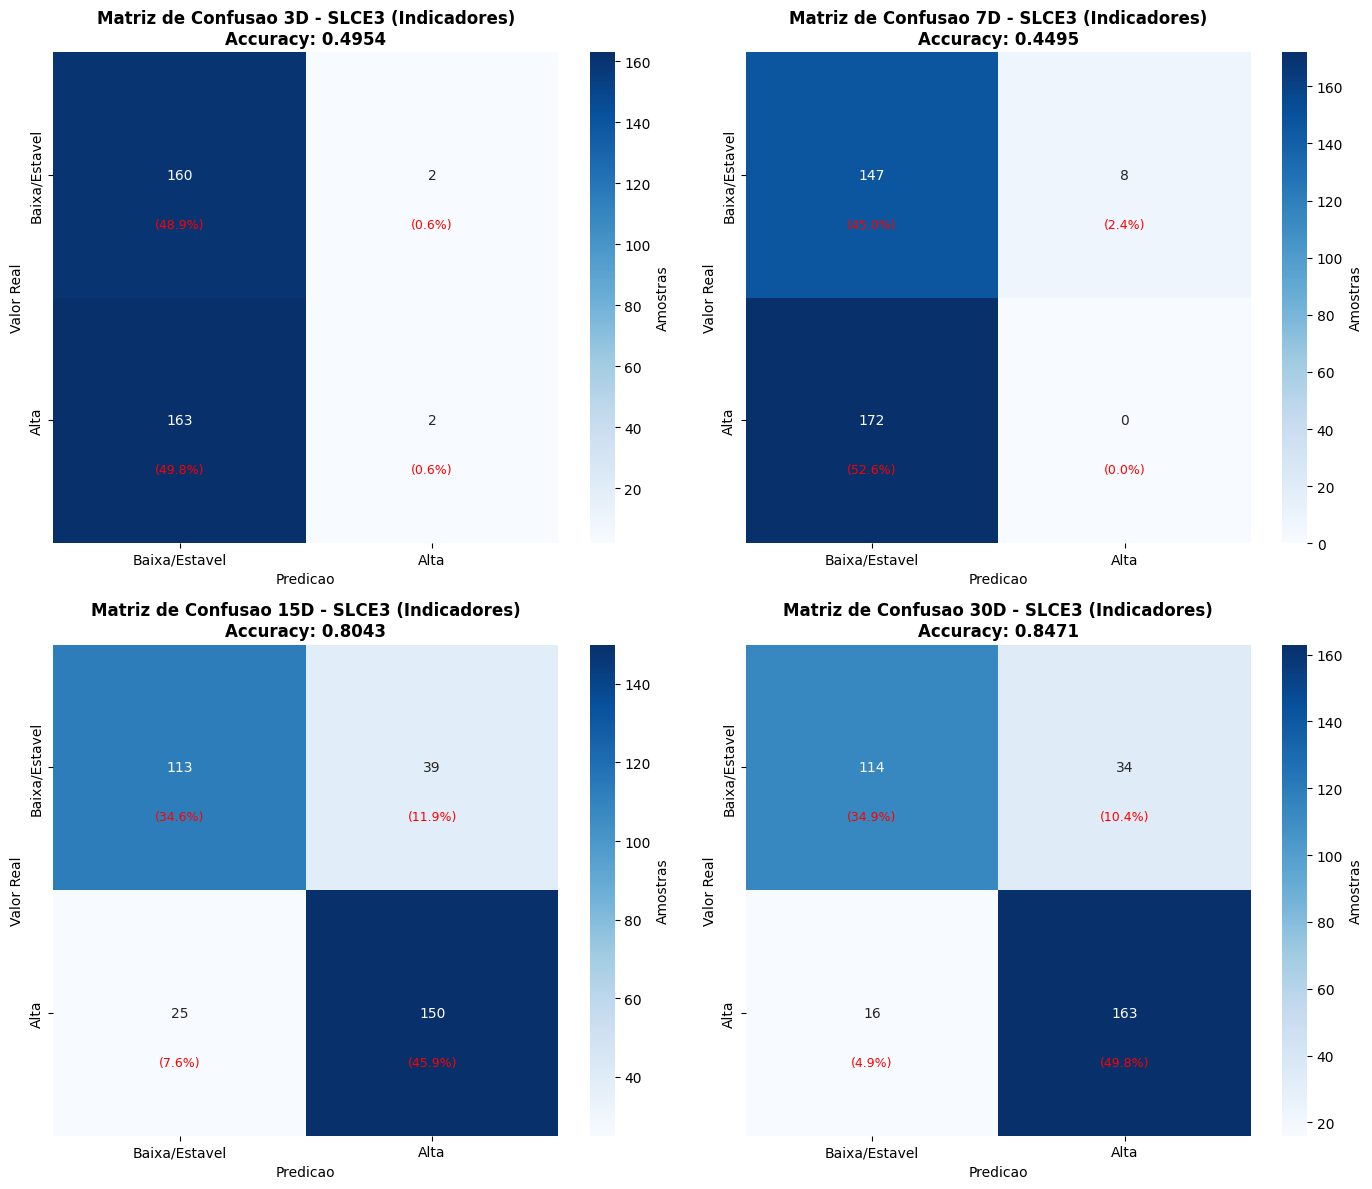

OK - Matrizes de confusao salvas


In [6]:
# Matrizes de Confusao
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models.items()):
    y_test = model_data['y_test']
    y_pred = model_data['y_pred']

    cm = confusion_matrix(y_test, y_pred)

    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Baixa/Estavel', 'Alta'],
                yticklabels=['Baixa/Estavel', 'Alta'],
                cbar_kws={'label': 'Amostras'})

    ax.set_title(f'Matriz de Confusao {period.upper()} - SLCE3 (Indicadores)\nAccuracy: {model_data["accuracy"]:.4f}', fontweight='bold')
    ax.set_xlabel('Predicao')
    ax.set_ylabel('Valor Real')

    # Adicionar porcentagens
    total = cm.sum()
    for i in range(2):
        for j in range(2):
            pct = (cm[i, j] / total) * 100
            ax.text(j + 0.5, i + 0.7, f'({pct:.1f}%)', ha='center', va='center', fontsize=9, color='red')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}matriz_confusao_{company_lower}_{DATASET_LABEL}.png', dpi=300, bbox_inches='tight')
plt.show()
print('OK - Matrizes de confusao salvas')


### Curvas ROC


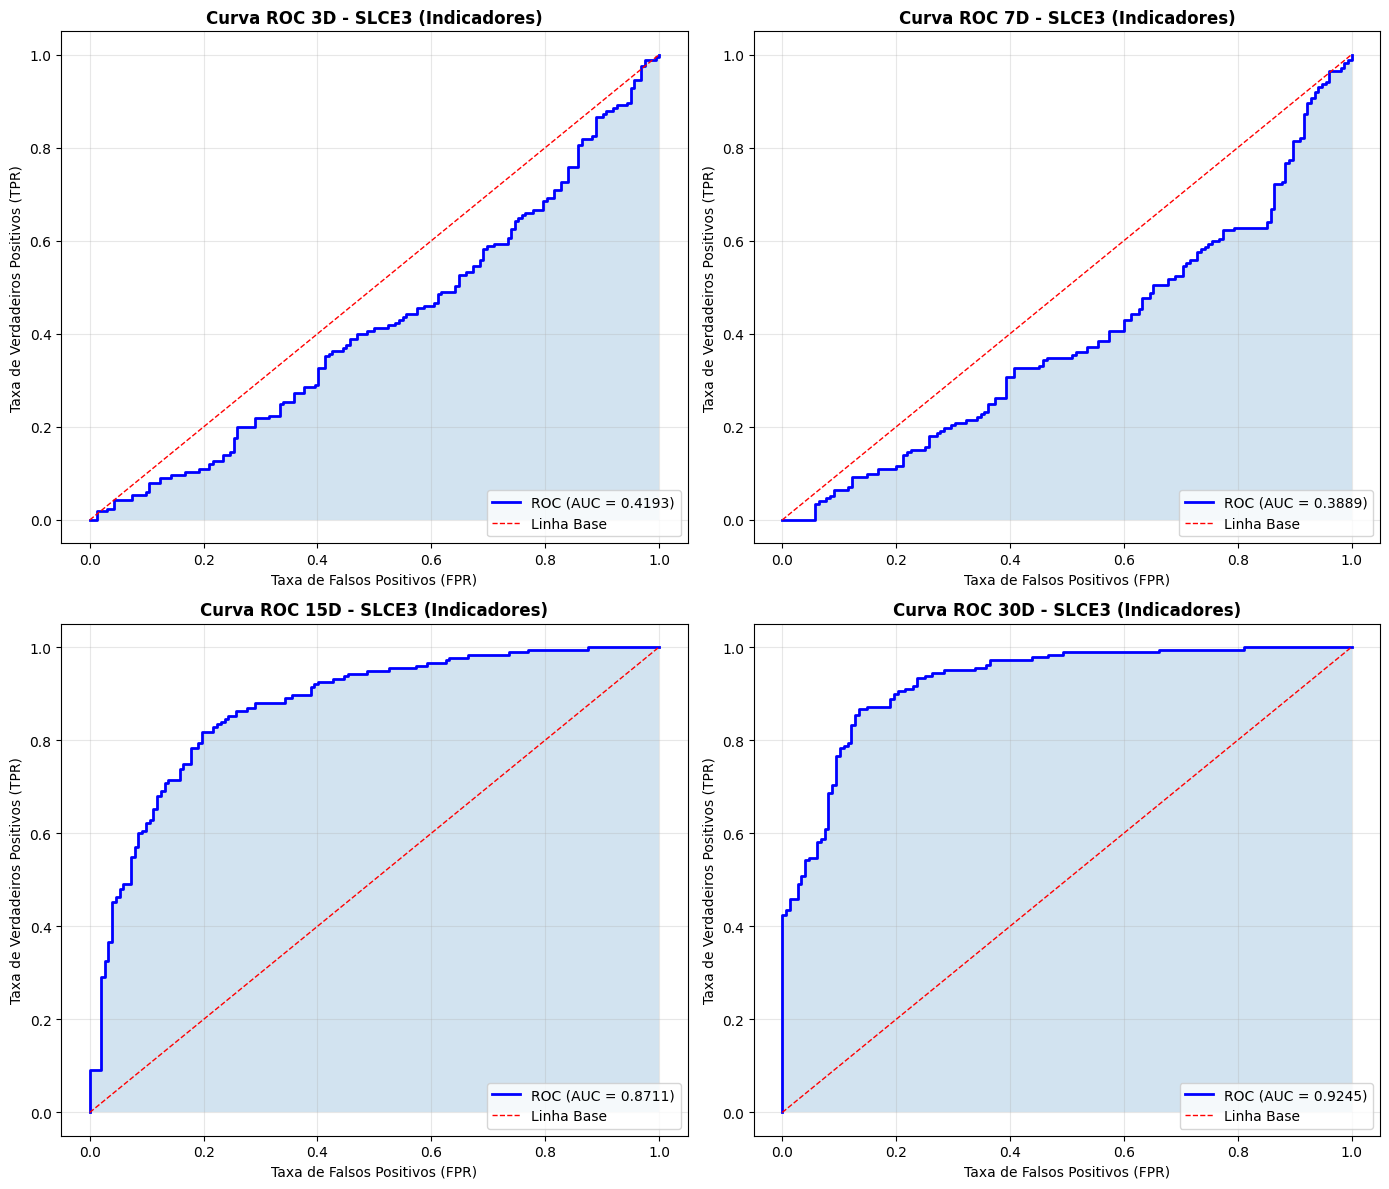

OK - Curvas ROC salvas


In [7]:
# Curvas ROC
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models.items()):
    y_test = model_data['y_test']
    y_pred_proba = model_data['y_pred_proba']
    auc = model_data['auc_roc']

    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

    ax = axes[idx]
    ax.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC = {auc:.4f})')
    ax.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Linha Base')
    ax.fill_between(fpr, tpr, alpha=0.2)

    ax.set_title(f'Curva ROC {period.upper()} - SLCE3 (Indicadores)', fontweight='bold')
    ax.set_xlabel('Taxa de Falsos Positivos (FPR)')
    ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}curva_roc_{company_lower}_{DATASET_LABEL}.png', dpi=300, bbox_inches='tight')
plt.show()
print('OK - Curvas ROC salvas')


### Comparacao das Metricas por Horizonte


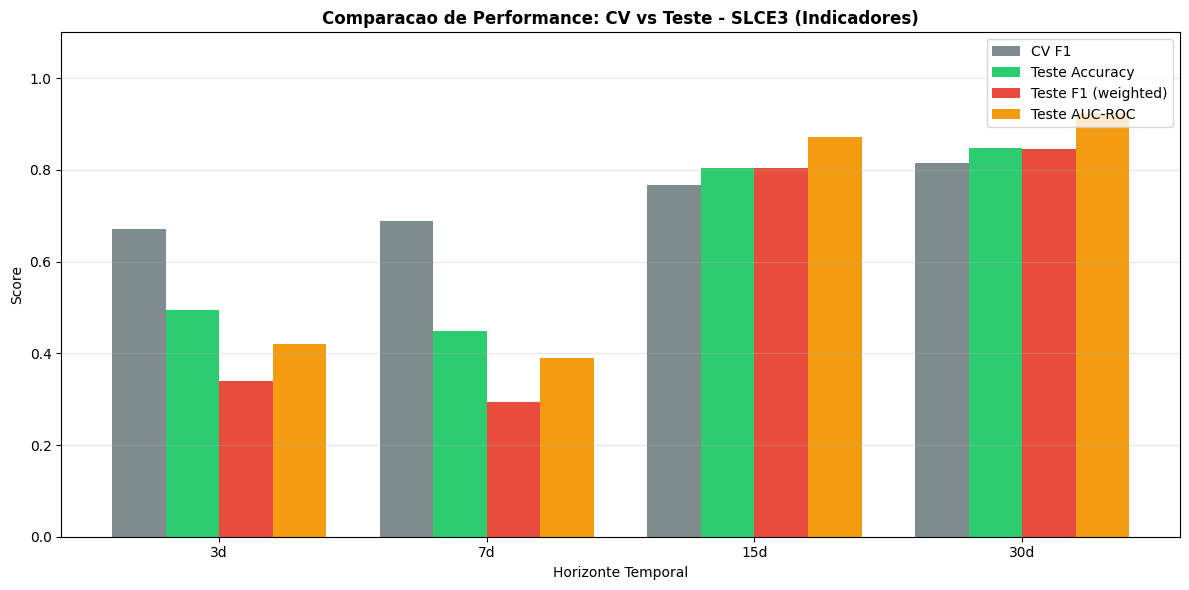

OK - Grafico de comparacao de metricas salvo


In [8]:
# Comparacao das metricas em Teste Final e score de CV
cv_f1_vals = [models[p]['best_cv_score'] for p in periods]
accuracy_vals = [models[p]['accuracy'] for p in periods]
f1_vals = [models[p]['f1'] for p in periods]
auc_vals = [models[p]['auc_roc'] for p in periods]

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(periods))
width = 0.2

bars1 = ax.bar(x - 1.5*width, cv_f1_vals, width, label='CV F1', color='#7f8c8d')
bars2 = ax.bar(x - 0.5*width, accuracy_vals, width, label='Teste Accuracy', color='#2ecc71')
bars3 = ax.bar(x + 0.5*width, f1_vals, width, label='Teste F1 (weighted)', color='#e74c3c')
bars4 = ax.bar(x + 1.5*width, auc_vals, width, label='Teste AUC-ROC', color='#f39c12')

ax.set_xlabel('Horizonte Temporal')
ax.set_ylabel('Score')
ax.set_title('Comparacao de Performance: CV vs Teste - SLCE3 (Indicadores)', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(periods)
ax.legend(loc='upper right')
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}comparacao_metricas_{company_lower}_{DATASET_LABEL}.png', dpi=300, bbox_inches='tight')
plt.show()
print('OK - Grafico de comparacao de metricas salvo')


### Evolucao das Metricas por Horizonte


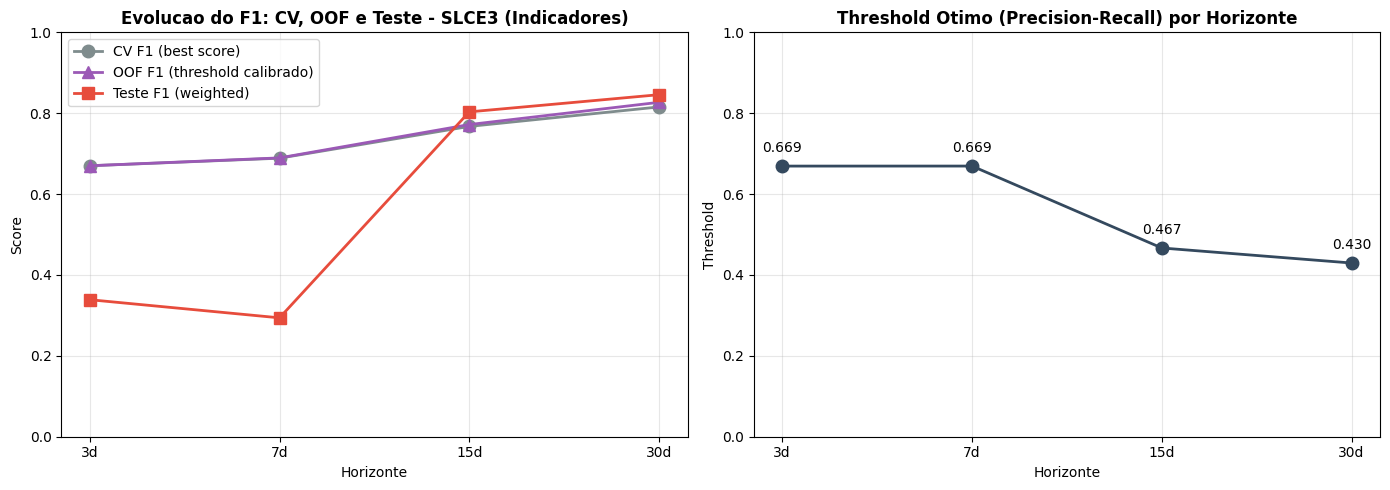

OK - Graficos de evolucao salvos


In [9]:
# Evolucao das metricas com destaque para calibracao de threshold
threshold_vals = [models[p]['optimal_threshold'] for p in periods]
f1_oof_vals = [models[p]['val_f1_oof'] for p in periods]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot F1 em CV/OOF/Teste
axes[0].plot(periods, cv_f1_vals, marker='o', linewidth=2, markersize=9, label='CV F1 (best score)', color='#7f8c8d')
axes[0].plot(periods, f1_oof_vals, marker='^', linewidth=2, markersize=9, label='OOF F1 (threshold calibrado)', color='#9b59b6')
axes[0].plot(periods, f1_vals, marker='s', linewidth=2, markersize=9, label='Teste F1 (weighted)', color='#e74c3c')
axes[0].set_title('Evolucao do F1: CV, OOF e Teste - SLCE3 (Indicadores)', fontweight='bold')
axes[0].set_xlabel('Horizonte')
axes[0].set_ylabel('Score')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1)

# Plot threshold calibrado por horizonte
axes[1].plot(periods, threshold_vals, marker='o', linewidth=2, markersize=9, color='#34495e')
axes[1].set_title('Threshold Otimo (Precision-Recall) por Horizonte', fontweight='bold')
axes[1].set_xlabel('Horizonte')
axes[1].set_ylabel('Threshold')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1)

for i, v in enumerate(threshold_vals):
    axes[1].annotate(f'{v:.3f}', (periods[i], v), textcoords='offset points', xytext=(0, 10), ha='center')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}evolucao_metricas_{company_lower}_{DATASET_LABEL}.png', dpi=300, bbox_inches='tight')
plt.show()
print('OK - Graficos de evolucao salvos')


### Metricas da Classe Alta (Positiva)


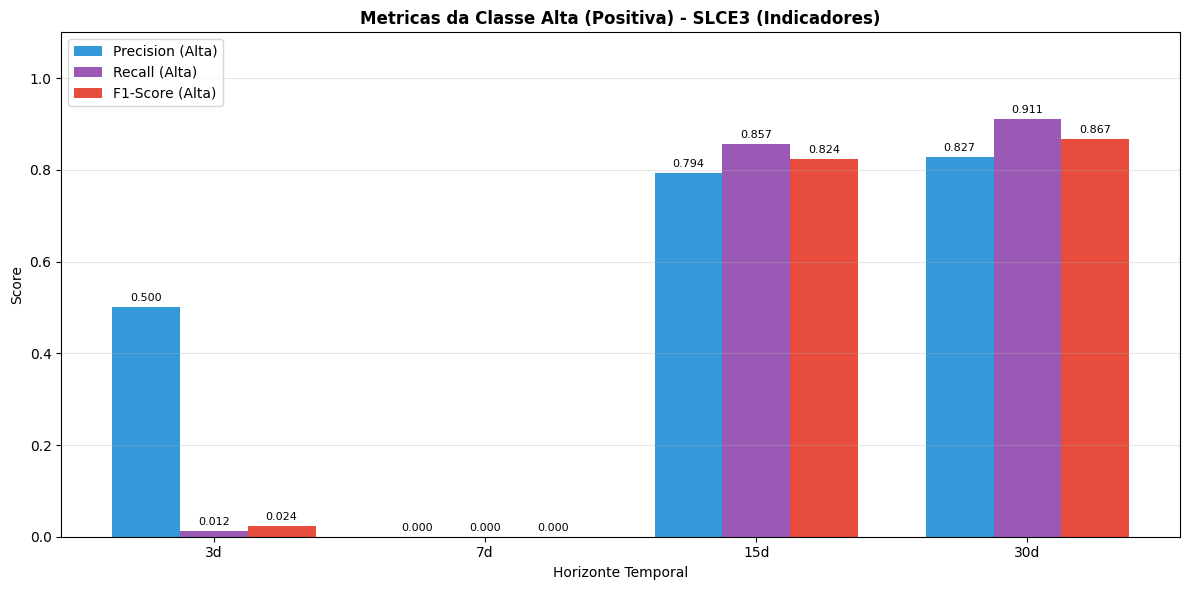

OK - Metricas da classe Alta salvas


In [10]:
# Metricas especificas da classe Alta
precision_alta_vals = [models[p]['precision_alta'] for p in periods]
recall_alta_vals = [models[p]['recall_alta'] for p in periods]
f1_alta_vals = [models[p]['f1_alta'] for p in periods]

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(periods))
width = 0.25

bars1 = ax.bar(x - width, precision_alta_vals, width, label='Precision (Alta)', color='#3498db')
bars2 = ax.bar(x, recall_alta_vals, width, label='Recall (Alta)', color='#9b59b6')
bars3 = ax.bar(x + width, f1_alta_vals, width, label='F1-Score (Alta)', color='#e74c3c')

ax.set_xlabel('Horizonte Temporal')
ax.set_ylabel('Score')
ax.set_title('Metricas da Classe Alta (Positiva) - SLCE3 (Indicadores)', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(periods)
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')

# Adicionar valores nas barras
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}metricas_classe_alta_{company_lower}_{DATASET_LABEL}.png', dpi=300, bbox_inches='tight')
plt.show()
print('OK - Metricas da classe Alta salvas')


### Relatorio de Classificacao Detalhado


In [11]:
# Relatorio de classificacao detalhado
print('\n' + '='*60)
print('RELATORIO DE CLASSIFICACAO DETALHADO - SLCE3 (INDICADORES)')
print('='*60)

for period, model_data in models.items():
    print(f"\n{'-'*50}")
    print(f'HORIZONTE: {period.upper()}')
    print(f"{'-'*50}")
    print(classification_report(model_data['y_test'], model_data['y_pred'],
                                target_names=['Baixa/Estavel', 'Alta']))



RELATORIO DE CLASSIFICACAO DETALHADO - SLCE3 (INDICADORES)

--------------------------------------------------
HORIZONTE: 3D
--------------------------------------------------
               precision    recall  f1-score   support

Baixa/Estavel       0.50      0.99      0.66       162
         Alta       0.50      0.01      0.02       165

     accuracy                           0.50       327
    macro avg       0.50      0.50      0.34       327
 weighted avg       0.50      0.50      0.34       327


--------------------------------------------------
HORIZONTE: 7D
--------------------------------------------------
               precision    recall  f1-score   support

Baixa/Estavel       0.46      0.95      0.62       155
         Alta       0.00      0.00      0.00       172

     accuracy                           0.45       327
    macro avg       0.23      0.47      0.31       327
 weighted avg       0.22      0.45      0.29       327


---------------------------------------

### Resumo Final


In [12]:
print('\n' + '=' * 70)
print('RESUMO FINAL - CLASSIFICACAO VIA REDE NEURAL SLCE3 (DATASET INDICADORES)')
print('=' * 70)

print('\nMETODOLOGIA:')
print('  1. Train + Validacao (Dev): 80% dos dados (estratificado)')
print('  2. Teste Final (Holdout): 20% dos dados (estratificado)')
print('  3. Dentro do Dev: StratifiedKFold (5 folds) + RandomizedSearchCV')
print('  4. Pipeline anti-leakage: SimpleImputer(mediana) + StandardScaler + MLPClassifier')
print("  5. MLPClassifier: solver='adam', early_stopping=True, max_iter=1000")
print('  6. Metrica de selecao de hiperparametros: F1 (classe positiva)')
print('  7. Calibracao de threshold por Precision-Recall usando previsoes OOF no Dev')

print('\nFEATURES UTILIZADAS:')
print(f'  - Total: {len(all_features)} features')
print(f'  - Base (OHLC): {base_features}')
print(f'  - Indicadores agro (lags): {agro_lag_features}')
print(f'  - Extras (Indicadores): {technical_indicators}')

print('\nMetricas por horizonte:')
for period in periods:
    m = models[period]
    print(
        f"  {period}: CV_F1={m['best_cv_score']:.4f}, "
        f"Thr={m['optimal_threshold']:.4f}, "
        f"OOF_F1={m['val_f1_oof']:.4f}, "
        f"Teste_Acc={m['accuracy']:.4f}, "
        f"Teste_F1w={m['f1']:.4f}, "
        f"Teste_AUC={m['auc_roc']:.4f}"
    )

best_period = max(periods, key=lambda p: models[p]['f1_alta'])
print(f"\nMelhor horizonte para classe Alta (F1): {best_period} -> {models[best_period]['f1_alta']:.4f}")

print('\nArquivos gerados:')
print(f'  - metricas_{company_lower}_{DATASET_LABEL}.csv')
print(f'  - matriz_confusao_{company_lower}_{DATASET_LABEL}.png')
print(f'  - curva_roc_{company_lower}_{DATASET_LABEL}.png')
print(f'  - comparacao_metricas_{company_lower}_{DATASET_LABEL}.png')
print(f'  - evolucao_metricas_{company_lower}_{DATASET_LABEL}.png')
print(f'  - metricas_classe_alta_{company_lower}_{DATASET_LABEL}.png')
print('=' * 70)



RESUMO FINAL - CLASSIFICACAO VIA REDE NEURAL SLCE3 (DATASET INDICADORES)

METODOLOGIA:
  1. Train + Validacao (Dev): 80% dos dados (estratificado)
  2. Teste Final (Holdout): 20% dos dados (estratificado)
  3. Dentro do Dev: StratifiedKFold (5 folds) + RandomizedSearchCV
  4. Pipeline anti-leakage: SimpleImputer(mediana) + StandardScaler + MLPClassifier
  5. MLPClassifier: solver='adam', early_stopping=True, max_iter=1000
  6. Metrica de selecao de hiperparametros: F1 (classe positiva)
  7. Calibracao de threshold por Precision-Recall usando previsoes OOF no Dev

FEATURES UTILIZADAS:
  - Total: 19 features
  - Base (OHLC): ['Close', 'Low', 'High', 'Open']
  - Indicadores agro (lags): ['agro_cambio_close_lag_1d', 'agro_cambio_close_lag_3d', 'agro_cambio_close_lag_6d', 'agro_cambio_close_lag_10d', 'agro_soja_close_lag_1d', 'agro_soja_close_lag_3d', 'agro_soja_close_lag_6d', 'agro_soja_close_lag_10d']
  - Extras (Indicadores): ['OBV', 'FWMA', 'TEMA', 'HLC3', 'BB_upper', 'BB_middle', 'BB_